# Run Harmonics on STARmap V1C dataset
Need additional packages: scanpy seaborn networkx

### Load the packages

In [ ]:
%reload_ext autoreload
%autoreload 2

import os
import time
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt

from Harmonics import *

import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=50, dpi_save=500)

from matplotlib import rcParams
rcParams["figure.dpi"] = 50
rcParams["savefig.dpi"] = 500
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'
rcParams['ps.fonttype'] = 42
# rcParams['font.family'] = 'Arial'
rcParams['savefig.transparent'] = True

In [ ]:
data_dir = '../../../Data/Spatial/Transcriptomics/STARmap_V1_Wang2018/'
save_dir = f'../../results/STARmap_V1_Wang2018/Harmonics/'
fig_dir = save_dir + 'figs/'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

Define a function to match the niche label to ground truth annotation and a function to change p values to corresponding star representation, used to show the results of additional tests implemented in Harmonics.

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

def match_cluster_labels(true_labels, est_labels):
    true_labels_arr = np.array(list(true_labels))
    est_labels_arr = np.array(list(est_labels))

    org_cat = list(np.sort(list(pd.unique(true_labels))))
    est_cat = list(np.sort(list(pd.unique(est_labels))))

    B = nx.Graph()
    B.add_nodes_from([i + 1 for i in range(len(org_cat))], bipartite=0)
    B.add_nodes_from([-j - 1 for j in range(len(est_cat))], bipartite=1)

    for i in range(len(org_cat)):
        for j in range(len(est_cat)):
            weight = np.sum((true_labels_arr == org_cat[i]) * (est_labels_arr == est_cat[j]))
            B.add_edge(i + 1, -j - 1, weight=-weight)

    match = nx.algorithms.bipartite.matching.minimum_weight_full_matching(B)

    if len(org_cat) >= len(est_cat):
        return np.array([match[-est_cat.index(c) - 1] - 1 for c in est_labels_arr])
    else:
        unmatched = [c for c in est_cat if not (-est_cat.index(c) - 1) in match.keys()]
        l = []
        for c in est_labels_arr:
            if (-est_cat.index(c) - 1) in match:
                l.append(match[-est_cat.index(c) - 1] - 1)
            else:
                l.append(len(org_cat) + unmatched.index(c))
        return np.array(l)
    
    
def p2stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

### Load dataset

In [ ]:
slice_name_list = ['V1']
adata = ad.read_h5ad(data_dir + 'processed/STARmap_V1Cortex.h5ad')
adata

AnnData object with n_obs × n_vars = 1207 × 1020
    obs: 'clusterid', 'celltype', 'layer'
    obsm: 'spatial'

In [5]:
adata.obs['celltype'].value_counts()

celltype
eL4        189
eL2/3      176
eL6-2      156
Oligo      154
Astro-2    105
Endo        86
eL6-1       80
eL5         69
Micro       52
PVALB       31
Reln        27
Astro-1     26
SST         23
VIP         13
HPC         10
Smc         10
Name: count, dtype: int64

### Run Harmonics

Instantiate Harmonics

In [6]:
iter=0
model = Harmonics_Model(adata, 
                        slice_name_list,
                        cond_list=None,  # default
                        cond_name_list=None,  # default
                        concat_label='slice_name',  # default
                        proportion_label=None,  # default
                        seed=1234+iter,  # default
                        parallel=False,  # recommand to set to True for large dataset and False for small dataset
                        verbose=True,  # default
                        )

Dataset comprises 1 slices, 1207 cells/spots in total.


Preprocess the data (Generating the connection graph and calculating neighborhood cell type destribution for cells)

In [7]:
model.preprocess(ct_key='celltype',  # default
                 spatial_key='spatial',  # default
                 method='joint',  # default
                 n_step=3,  # default
                 n_neighbors=20,  # default
                 cut_percentage=99,  # default
                 )

Generating Delaunay neighbor graph...


100%|██████████| 1/1 [00:00<00:00, 82.56it/s]


All done!

Performing graph completion...


100%|██████████| 1/1 [00:00<00:00,  6.91it/s]


All done!

The cell types of interest are:
Astro-1
Astro-2
Endo
HPC
Micro
Oligo
PVALB
Reln
SST
Smc
VIP
eL2/3
eL4
eL5
eL6-1
eL6-2

Generating one-hot matrix...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 399.50it/s]

All done!

Dataset comprises 16 cell types.

Calculating cell type distribution for microenvironments...
Microenvironments comprise 39.99 cells/spots on average. 
Minimum: 20, Maximum: 62



Perform overclustered initialization on the cell type distributions of cell neighborhoods. Resulting in *Qmax* niches. The distributions of niches are also computed. We set *Qmax* to 10 since this is a relatively small dataset.

In [8]:
model.initialize_clusters(dim_reduction=True,  # default
                          explained_var=None,  # default
                          n_components=None,  # default
                          n_components_max=100,  # default
                          standardize=True,  # default
                          method='kmeans',  # default 
                          Qmax=10, 
                          )

Performing dimension reduction...
Returning 16 principal components.

Initializing niches...


10 initial niches defined.



Perform hierarchical distribution matching to reduce the niche number to no less than *Qmin*. This step results in niche assignment under a sequence of different niche numbers (usually from *Qmax* to *Qmin*).

In [ ]:
model.hier_dist_match(assign_metric='jsd',  # default
                      weighted_merge=True,  # default
                      max_iters=100,  # default 
                      tol=1e-4,  # default 
                      test_kmeans=False,  # default
                      Qmin=2,  # default
                      )

Starting from 10 cell niches...

Assigning cells to cell niche...
Current state: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


 24%|██▍       | 24/100 [00:00<00:00, 230.93it/s]

100%|██████████| 100/100 [00:00<00:00, 231.43it/s]


Unconverged at iteration 100!
9 cell niches left.
Merging cell niche 6 and cell niche 2...
Done!

Assigning cells to cell niche...
Current state: [0, 1, 3, 4, 5, 6, 8, 9]


  3%|▎         | 3/100 [00:00<00:00, 166.21it/s]


...

Strictly converge at iteration 11.
4 cell niches left.
Merging cell niche 1 and cell niche 6...
Done!

Assigning cells to cell niche...
Current state: [0, 1, 4]


 15%|█▌        | 15/100 [00:00<00:00, 265.44it/s]


Strictly converge at iteration 16.
3 cell niches left.
Merging cell niche 0 and cell niche 4...
Done!

Assigning cells to cell niche...
Current state: [0, 1]


  7%|▋         | 7/100 [00:00<00:00, 325.97it/s]

Strictly converge at iteration 8.
2 cell niches left.
Niche count no more than 2.

Finished!



### Metric-guided solution selection
metric='jsd_v2': bootstrap-based minJSD strategy  
The results of niche assignments are saved in .obs[niche_key]

Automatically selecting best solution...


 44%|████▍     | 44/100 [00:00<00:00, 433.33it/s]

100%|██████████| 100/100 [00:00<00:00, 1713.67it/s]


Suggested range of niche count is [8, 9].
Recommended number of niches are [8]
Selecting 8 niches as the best solution.


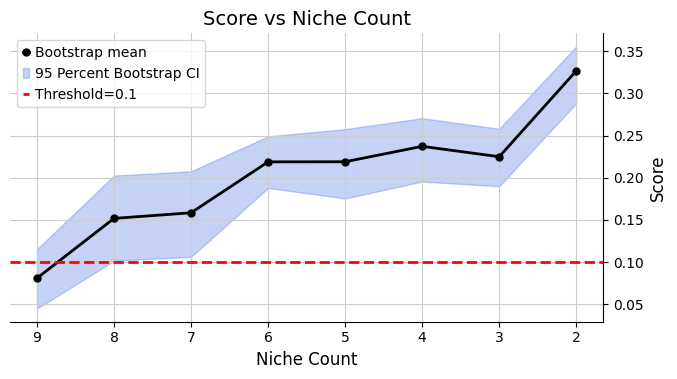

Done!



In [10]:
adata_list, adata_concat = model.select_solution(n_niche=None,  # default 
                                                 niche_key=f'niche_label',  # default 
                                                 auto=True,  # default 
                                                 metric='jsd_v2',  # default
                                                 threshold=0.1,  # default
                                                 return_adata=True,  # default
                                                 plot=True,  # default
                                                 save=False,  # default
                                                 fig_size=(7, 4), 
                                                 save_dir=save_dir, 
                                                 file_name=f'score_vs_nichecount_basic_{iter}.pdf',
                                                 )

Save the result

In [ ]:
adata_concat.write_h5ad(save_dir + f'Harmonics_result_{iter}.h5ad')

In [12]:
# adata = ad.read_h5ad(save_dir + f'Harmonics_result_0.h5ad')
# adata